# Learning intertwiners

Suppose we want to learn a linear map that commutes with the action of a
Hopf algebra $H$ — an *intertwiner*. The usual approach adds a penalty
$\|\rho_W(h) \circ T - T \circ \rho_V(h)\|$ to the loss and hopes.
`Intertwiner.chart` instead computes an isometry $Q$ onto the space
$\mathrm{Hom}_H(V, W)$, so that every value of the parameters gives an
intertwiner *by construction* and every intertwiner arises this way. The
parameters are what a training loop optimizes; equivariance is structural,
never a penalty.

Our example is anyon fusion in the toric code: the quantum double
$D(k[\mathbb{Z}/2])$. The point of taking a *genuinely quasitriangular*
Hopf algebra is at the end of the notebook — the braid group acts on the
learned parameters, and it does not factor through the symmetric group.

In [1]:
import numpy as np
from discopy.hopf import HopfAlgebra, Representation, Intertwiner
from discopy.tensor import Dim, Box, Id, Diagram

D = HopfAlgebra.cyclic(2).double()
assert D.is_valid() and D.is_quasitriangular()

anyons = [Representation[D].anyon(f, c) for f in (0, 1) for c in (1, -1)]
V = Representation[D].direct_sum(anyons)
assert V.is_module() and V == Dim(4)

## The chart of the fusion space

`V` is the sum of the four anyons $1, e, m, \psi$. Each ordered pair of
anyons fuses to a unique third label, so the fusion space
$\mathrm{Hom}_H(V \otimes V, V)$ has dimension $16$: the chart is a
parametrised intertwiner $Q : \mathtt{Dim}(16) \otimes V \otimes V \to
V$, one orthonormal basis vector per parameter.

In [2]:
Q = Intertwiner[D].chart(V @ V, V)
assert Q.dom == Dim(16, 4, 4) and Q.cod == Dim(4)
print(Q.dom, '->', Q.cod)

Dim(16, 4, 4) -> Dim(4)


The parameters spectate in the intertwiner axiom, which therefore
holds for every value at once. We check it as an equation of diagrams and
draw the left-hand side as the tensor network it contracts to:

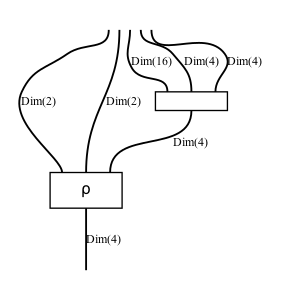

In [3]:
lhs = Id(D.ty) @ Q >> V.action
rhs = Diagram.swap(D.ty, Dim(16)) @ Id(Dim(4, 4)) \
    >> Id(Dim(16)) @ (V @ V).action >> Q
assert lhs.eval(dtype=complex).is_close(rhs.eval(dtype=complex))
lhs.to_map().draw()

## Recovering a fusion map from few examples

An unknown intertwiner $T_\star : V \otimes V \to V$ has $64$ entries,
but we only get $m = 10$ noisy input–output examples
$y_i = T_\star x_i + \text{noise}$, i.e. $40$ scalar equations.
Unconstrained recovery is underdetermined ($40 < 64$); in the chart it is
an overdetermined least-squares problem in $16$ parameters.

In [4]:
rng = np.random.default_rng(11)
basis = Q.eval(dtype=complex).array.reshape(16, 16, 4)
theta_star = rng.standard_normal(16)
T_star = np.einsum('k,kva->va', theta_star, basis)

m = 10
probes = rng.standard_normal((m, 16)) / 4
outputs = probes @ T_star + .01 * rng.standard_normal((m, 4))

In [5]:
design = np.einsum('iv,kva->iak', probes, basis).reshape(4 * m, 16)
theta_chart = np.linalg.lstsq(design, outputs.reshape(-1), rcond=None)[0]
T_chart = np.einsum('k,kva->va', theta_chart, basis)
T_free = np.linalg.lstsq(
    np.kron(probes, np.eye(4)), outputs.reshape(-1), rcond=None)[0]
T_free = T_free.reshape(16, 4)

rho = (V @ V).action.eval(dtype=complex).array.reshape(4, 16, 16)
sigma = V.action.eval(dtype=complex).array.reshape(4, 4, 4)

def relative_error(T):
    return np.linalg.norm(T - T_star) / np.linalg.norm(T_star)

def violation(T):
    return max(np.linalg.norm(sigma[i].T @ T.T - T.T @ rho[i].T)
               for i in range(4))

for name, T in [("chart (16 parameters)", T_chart),
                ("unconstrained (64 entries)", T_free)]:
    print(f"{name:28s} error {relative_error(T):7.1%}   "
          f"equivariance violation {violation(T):.2e}")

chart (16 parameters)        error    2.1%   equivariance violation 0.00e+00
unconstrained (64 entries)   error   65.8%   equivariance violation 1.79e+00


The chart recovers the fusion map an order of magnitude better from
the same data, and its reconstruction commutes with the action *exactly*
— the unconstrained solution violates the symmetry by as much as it
recovers.

## Differentiating through the tensor network

$Q\theta$ is linear in $\theta$, so least squares was enough above. The
point of this section is the mechanics: the chart is a diagram, so the
parameters, the chart and the probes compose into one tensor network,
contracted by a single `einsum` under the `jax` backend — and the loss
differentiates through the contraction. The same plumbing works when the
chart sits inside a bigger, nonlinear model.

In [6]:
import jax
import jax.numpy as jnp
from discopy.matrix import backend

def loss(theta):
    with backend('jax'):
        network = Box[complex]('x', Dim(1), Dim(m, 4, 4),
                               jnp.asarray(probes.reshape(m, 4, 4),
                                           dtype=complex)) \
            >> Id(Dim(m)) @ (
                Box[complex]('θ', Dim(1), Dim(16),
                             jnp.asarray(theta, dtype=complex))
                @ Id(Dim(4, 4)) >> Q)
        prediction = network.eval(dtype=complex).array
    residual = prediction - jnp.asarray(outputs, dtype=complex)
    return jnp.real(jnp.sum(residual.conj() * residual))

loss_jit, grad = jax.jit(loss), jax.jit(jax.grad(loss))
theta = jnp.zeros(16)
history = [float(loss_jit(theta))]
for _ in range(300):
    theta = theta - .5 * grad(theta)
    history.append(float(loss_jit(theta)))

relative_error(np.einsum('k,kva->va', np.asarray(theta.real), basis))

np.float64(0.020836425064033604)

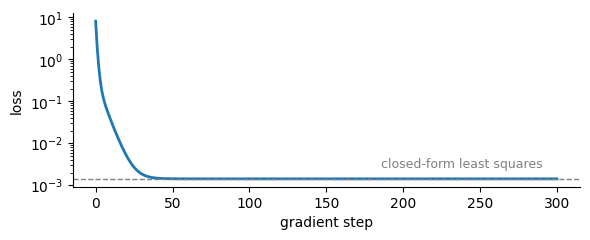

In [7]:
import matplotlib.pyplot as plt

optimum = float(np.sum(np.abs(design @ theta_chart
                              - outputs.reshape(-1)) ** 2))
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.semilogy(history, lw=2)
ax.axhline(optimum, ls='--', c='gray', lw=1)
ax.annotate('closed-form least squares', xy=(len(history) - 1, optimum),
            xytext=(-10, 8), textcoords='offset points',
            ha='right', fontsize=9, color='gray')
ax.set_xlabel('gradient step')
ax.set_ylabel('loss')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## The braid group acts on the parameters

Pre-composing with the braiding of two strands preserves the space of
intertwiners, so it induces matrices $B_1, B_2$ on the parameters of
$\mathrm{Hom}_H(V^{\otimes 3}, V)$ — a representation of the braid group
$B_3$. Because $D(k[\mathbb{Z}/2])$ is quasitriangular and not a group
algebra, the representation is genuinely braided: $B_i^2 \neq 1$ (the
$e$–$m$ double braiding is $-1$), while Yang–Baxter holds exactly.

In [8]:
Q3 = Intertwiner[D].chart(V @ V @ V, V)
r = Q3.dom.inside[0]
slices = Q3.eval(dtype=complex).array.reshape(r, 64, 4)
braid = Intertwiner[D].braid(V, V).eval(dtype=complex).array
braid = braid.reshape(16, 16).T
b1, b2 = [
    np.einsum('kva,vw,lwa->kl', slices.conj(), c, slices)
    for c in (np.kron(braid, np.eye(4)), np.kron(np.eye(4), braid))]
assert np.allclose(b1 @ b1.conj().T, np.eye(r))
assert np.allclose(b1 @ b2 @ b1, b2 @ b1 @ b2)
assert not np.allclose(b1 @ b1, np.eye(r))
r

64

## Where this goes

* The chart needs no semisimplicity — it is a nullspace, so it works for
  Sweedler's Hopf algebra and other non-semisimple examples where no
  equivariant projector exists.
* A chart is an ordinary box: it can sit inside any diagram evaluated by
  the ribbon `Functor`, e.g. as a learnable fusion vertex in a knot
  invariant or a tensor-network model.